<a href="https://colab.research.google.com/github/KatKolesnyk/ecommerce-analytics/blob/main/Ecommerce_Sales_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce Sales Analytics: SQL Extraction, Python EDA & Statistical Analysis

**Project overview:**
This project analyzes user session and order data from an e-commerce platform, combining data extracted directly from a BigQuery data warehouse with exploratory and statistical analysis in Python. The dataset joins six source tables — sessions, session metadata, subscriber accounts, orders, and products — to build a single analytical view covering traffic, device, geography, subscription, and purchase behavior.

**Objectives:**
- Extract and join the required tables from BigQuery via a parameterized SQL query
- Profile the resulting dataset (structure, data types, completeness, time coverage)
- Explore sales performance across geography, product categories, devices, and traffic sources
- Analyze sales dynamics over time and test for seasonality
- Test statistical relationships (correlation) and group differences (hypothesis testing) across key business segments
- Summarize findings into an interactive Tableau dashboard

**Data source:** `data-analytics-mate.DA` (Google BigQuery)

# 1. Data Extraction (SQL + BigQuery)

In [ ]:
!pip install --upgrade google-cloud-bigquery

from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np

# Authenticate and create a BigQuery client
auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")

**Query design notes:**
- `LEFT JOIN` is used throughout starting from `session`, so every session and every order is preserved — even sessions with no linked account (most users are not registered) and sessions with no purchase.
- Column names are renamed explicitly (`session_date`, `traffic_source`, `product_name`, etc.) to avoid ambiguous or duplicate names (e.g. `session_params.name` vs `product.name`) and to keep the dataset self-documenting.
- `medium` and `name` from `session_params` are kept as two separate fields (`traffic_source`, `traffic_source_info`) since they represent different levels of detail about the traffic source.

In [ ]:
query = """
SELECT
  s.date AS session_date,
  s.ga_session_id AS session_id,
  sp.continent,
  sp.country,
  sp.device AS device_type,
  sp.browser,
  sp.mobile_model_name AS mobile_model,
  sp.operating_system,
  sp.language AS browser_language,
  sp.medium AS traffic_source,
  sp.name AS traffic_source_info,
  sp.channel AS traffic_channel,
  a.id AS account_id,
  a.is_verified AS is_email_verified,
  a.is_unsubscribed,
  p.category AS product_category,
  p.name AS product_name,
  p.price AS product_price,
  p.short_description AS product_description
FROM `data-analytics-mate.DA.session` s
LEFT JOIN `data-analytics-mate.DA.session_params` sp
ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` a
ON acs.account_id = a.id
LEFT JOIN `data-analytics-mate.DA.order` o
ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
ON o.item_id = p.item_id
ORDER BY s.date
"""

data = client.query(query).to_dataframe(create_bqstorage_client=False)
data.head()

,session_date,session_id,continent,country,device_type,browser,mobile_model,operating_system,browser_language,traffic_source,traffic_source_info,traffic_channel,account_id,is_email_verified,is_unsubscribed,product_category,product_name,product_price,product_description
0,2020-11-01,65223751,Americas,United States,mobile,Chrome,<Other>,Web,en-us,organic,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


# 2. Dataset Overview

In [ ]:
# General information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   session_date         349545 non-null  dbdate 
 1   session_id           349545 non-null  Int64  
 2   continent            349545 non-null  object 
 3   country              349545 non-null  object 
 4   device_type          349545 non-null  object 
 5   browser              349545 non-null  object 
 6   mobile_model         349545 non-null  object 
 7   operating_system     349545 non-null  object 
 8   browser_language     235279 non-null  object 
 9   traffic_source       349545 non-null  object 
 10  traffic_source_info  349545 non-null  object 
 11  traffic_channel      349545 non-null  object 
 12  account_id           27945 non-null   Int64  
 13  is_email_verified    27945 non-null   Int64  
 14  is_unsubscribed      27945 non-null   Int64  
 15  product_category 

In [ ]:
# Changing data types
# NOTE: account_id / is_email_verified / is_unsubscribed use the nullable "object" dtype (not plain str)
# so that missing values stay as real NA instead of being converted into the literal string "<NA>"
data["session_date"] = pd.to_datetime(data["session_date"], format="%Y-%m-%d")
data["session_id"] = data["session_id"].astype(str)
data["account_id"] = data["account_id"].astype("object")
data["is_email_verified"] = data["is_email_verified"].astype("object")
data["is_unsubscribed"] = data["is_unsubscribed"].astype("object")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   session_date         349545 non-null  datetime64[ns]
 1   session_id           349545 non-null  object        
 2   continent            349545 non-null  object        
 3   country              349545 non-null  object        
 4   device_type          349545 non-null  object        
 5   browser              349545 non-null  object        
 6   mobile_model         349545 non-null  object        
 7   operating_system     349545 non-null  object        
 8   browser_language     235279 non-null  object        
 9   traffic_source       349545 non-null  object        
 10  traffic_source_info  349545 non-null  object        
 11  traffic_channel      349545 non-null  object        
 12  account_id           27945 non-null   object        
 13  is_email_verif

## 2.1 Dataset Description

In [ ]:
# Column type breakdown
# session_id / account_id are unique identifiers, not numeric measures,
# so they are reported separately from the true numeric metric (product_price)
identifier_cols = ["session_id", "account_id"]
numeric_cols = [c for c in data.select_dtypes(include=["number"]).columns if c not in identifier_cols]
categorical_cols = [c for c in data.select_dtypes(include=["object", "string"]).columns if c not in identifier_cols]
datetime_cols = data.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns.tolist()

print(f"Total columns: {data.shape[1]}")
print(f"Identifier columns ({len(identifier_cols)}): {identifier_cols}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Datetime columns ({len(datetime_cols)}): {datetime_cols}")

Total columns: 19
Identifier columns (2): ['session_id', 'account_id']
Numeric columns (1): ['product_price']
Categorical columns (15): ['continent', 'country', 'device_type', 'browser', 'mobile_model', 'operating_system', 'browser_language', 'traffic_source', 'traffic_source_info', 'traffic_channel', 'is_email_verified', 'is_unsubscribed', 'product_category', 'product_name', 'product_description']
Datetime columns (1): ['session_date']


In [ ]:
# Core dataset facts
print(f"Unique sessions: {data['session_id'].nunique():,}")
print(f"Total rows: {data.shape[0]:,} "
      f"(equal to unique sessions - no session in this period has more than one purchased item)")
print(f"Date range: {data['session_date'].min().date()} - {data['session_date'].max().date()} "
      f"({(data['session_date'].max() - data['session_date'].min()).days} days)")

Unique sessions: 349,545
Total rows: 349,545 (equal to unique sessions - no session in this period has more than one purchased item)
Date range: 2020-11-01 - 2021-01-31 (91 days)


**Missing value strategy — replace, don't drop:**
Every missing pattern here reflects a real business state (visitor not registered, session ended without a purchase), not a data error — dropping these rows would silently remove ~90% of the dataset and destroy the ability to analyze browsing-without-buying behavior. Instead:
- Categorical fields get explicit, human-readable labels instead of `NaN` (useful directly in pivot tables and Tableau).
- `product_price` is intentionally **left as `NaN`**, not filled with `0` — a `0` would corrupt any average/median price calculation. It is only filled at aggregation time (e.g. `data["product_price"].fillna(0).sum()` for total revenue).
- The registration flag is captured *before* filling `account_id`, since after filling it with a text label, `NaN`-detection is no longer possible.

In [ ]:
# Capture registration status BEFORE filling missing values below —
# once account_id is filled with a label, .notna() can no longer tell registered from unregistered
data["is_registered"] = data["account_id"].notna()
print(data["is_registered"].value_counts())
print(f"Registered share: {data['is_registered'].mean() * 100:.2f}%")

is_registered
False    321600
True      27945
Name: count, dtype: int64
Registered share: 7.99%


In [ ]:
# Missing values summary (share of rows, not of unique sessions)
missing = data.isna().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_summary

,missing_count,missing_pct
account_id,321600,92.01
is_email_verified,321600,92.01
is_unsubscribed,321600,92.01
product_category,316007,90.41
product_price,316007,90.41
product_name,316007,90.41
product_description,316007,90.41
browser_language,114266,32.69


In [ ]:
# Human-readable label instead of NaN, for pivot tables / dashboards
data["account_id"] = data["account_id"].fillna("Not registered")
data["is_email_verified"] = data["is_email_verified"].fillna("Not registered")
data["is_unsubscribed"] = data["is_unsubscribed"].fillna("Not registered")

data["product_category"] = data["product_category"].fillna("No purchase")
data["product_name"] = data["product_name"].fillna("No purchase")
data["product_description"] = data["product_description"].fillna("No purchase")
# product_price stays NaN — filled with 0 only at aggregation time, e.g.:
# data["product_price"].fillna(0).sum()

data["browser_language"] = data["browser_language"].fillna("unknown")

In [ ]:
# Verification: confirm categorical fields are now fully filled (product_price stays NaN by design)
data.isna().sum()

,0
session_date,0
session_id,0
continent,0
country,0
device_type,0
browser,0
mobile_model,0
operating_system,0
browser_language,0
traffic_source,0


In [ ]:
# Cardinality re-check after filling — "No purchase" now appears as its own category
for col in ["continent", "country", "device_type", "traffic_channel", "product_category"]:
    print(f"{col}: {data[col].nunique()} unique values")
print()
print(f"Fully duplicated rows: {data.duplicated().sum()}")

continent: 6 unique values
country: 108 unique values
device_type: 3 unique values
traffic_channel: 5 unique values
product_category: 15 unique values

Fully duplicated rows: 0


**Dataset summary:**

The dataset contains **19 columns**: 2 identifiers (`session_id`, `account_id`), 1 true numeric measure (`product_price`), 15 categorical fields, and 1 datetime field (`session_date`). Row count equals the number of unique sessions — **349,545** — meaning no session in this three-month window resulted in more than one purchased item, so no session-level duplication needs to be accounted for downstream. The data spans **2020-11-01 to 2021-01-31 (91 days)**, roughly a single quarter — long enough to explore weekly patterns and short-term trends, but too short to draw conclusions about annual seasonality.

Missing values follow three distinct, business-explainable patterns rather than indicating data quality issues:
- **`account_id`, `is_email_verified`, `is_unsubscribed` — 92.01% missing.** Only **7.99%** of sessions (27,945 of 349,545) are linked to a registered account; the vast majority of traffic is anonymous browsing. This split was captured in a dedicated `is_registered` flag *before* filling, since filling `account_id` with a label would otherwise make registered and unregistered sessions indistinguishable.
- **`product_category`, `product_name`, `product_price`, `product_description` — 90.41% missing.** These are sessions that did not end in a purchase — expected, since browsing without buying is the majority behavior on any e-commerce site.
- **`browser_language` — 32.69% missing**, a smaller and less obvious gap, most likely caused by browser privacy settings or GA being unable to detect a language header — worth a quick follow-up check against `device_type`/`browser` later to see if the gap concentrates in specific segments.

All categorical gaps were replaced with explicit labels (`"Not registered"`, `"No purchase"`) rather than dropped, preserving the full dataset for behavioral analysis. `product_price` was deliberately **left as `NaN`** rather than filled with `0`, since a `0` would distort average and median price calculations; it will only be filled at aggregation time when computing totals such as revenue.

No fully duplicated rows were found, confirming the join logic didn't introduce artificial repetition. The dataset covers **108 countries across 6 continents**, **3 device types**, **5 traffic channels**, and **15 product-category values** (14 real categories plus the `"No purchase"` label) — enough categorical depth to support the segmented analysis in the sections that follow.

# 3. Sales & Orders Analysis by Segment

This section answers the core business questions about where revenue and orders come from — geography, product category, device, traffic source, and subscriber behavior. Throughout this section, "sales" refers to `product_price` summed over rows with a completed purchase (`product_category != "No purchase"`), and "orders" refers to the count of those purchased rows, since Section 2 confirmed each session accounts for exactly one purchased item in this dataset (rows == unique sessions), so no additional deduplication is needed.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Working subset: sessions that resulted in a purchase
purchased = data[data["product_category"] != "No purchase"].copy()
total_revenue = purchased["product_price"].sum()
total_orders = len(purchased)

print(f"Purchased sessions (orders): {total_orders:,} out of {len(data):,} total sessions "
      f"({total_orders / len(data) * 100:.2f}% conversion rate)")
print(f"Total revenue: ${total_revenue:,.2f}")

Purchased sessions (orders): 33,538 out of 349,545 total sessions (9.59% conversion rate)
Total revenue: $31,971,731.10


## 3.1 Top Continents and Countries by Sales and Orders

In [ ]:
continent_summary = purchased.groupby("continent").agg(
    revenue=("product_price", "sum"),
    orders=("session_id", "count")
).sort_values("revenue", ascending=False)
continent_summary["revenue_share_%"] = (continent_summary["revenue"] / total_revenue * 100).round(2)
continent_summary["orders_share_%"] = (continent_summary["orders"] / total_orders * 100).round(2)

top3_continents_revenue = continent_summary.sort_values("revenue", ascending=False).head(3)
top3_continents_orders = continent_summary.sort_values("orders", ascending=False).head(3)

print("Top-3 continents by revenue:")
display(top3_continents_revenue)
print("\nTop-3 continents by order count:")
display(top3_continents_orders)

Top-3 continents by revenue:


,revenue,orders,revenue_share_%,orders_share_%
continent,,,,
Americas,17665280.0,18553,55.25,55.32
Asia,7601298.3,7950,23.78,23.70
Europe,5934624.2,6261,18.56,18.67



Top-3 continents by order count:


,revenue,orders,revenue_share_%,orders_share_%
continent,,,,
Americas,17665280.0,18553,55.25,55.32
Asia,7601298.3,7950,23.78,23.70
Europe,5934624.2,6261,18.56,18.67


In [ ]:
country_summary = purchased.groupby("country").agg(
    revenue=("product_price", "sum"),
    orders=("session_id", "count")
).sort_values("revenue", ascending=False)

top5_countries_revenue = country_summary.sort_values("revenue", ascending=False).head(5)
top5_countries_orders = country_summary.sort_values("orders", ascending=False).head(5)

print("Top-5 countries by revenue:")
display(top5_countries_revenue)
print("\nTop-5 countries by order count:")
display(top5_countries_orders)

Top-5 countries by revenue:


,revenue,orders
country,,
United States,13943553.9,14673
India,2809762.0,3029
Canada,2437921.0,2560
United Kingdom,938317.9,1029
France,710692.8,678



Top-5 countries by order count:


,revenue,orders
country,,
United States,13943553.9,14673
India,2809762.0,3029
Canada,2437921.0,2560
United Kingdom,938317.9,1029
France,710692.8,678


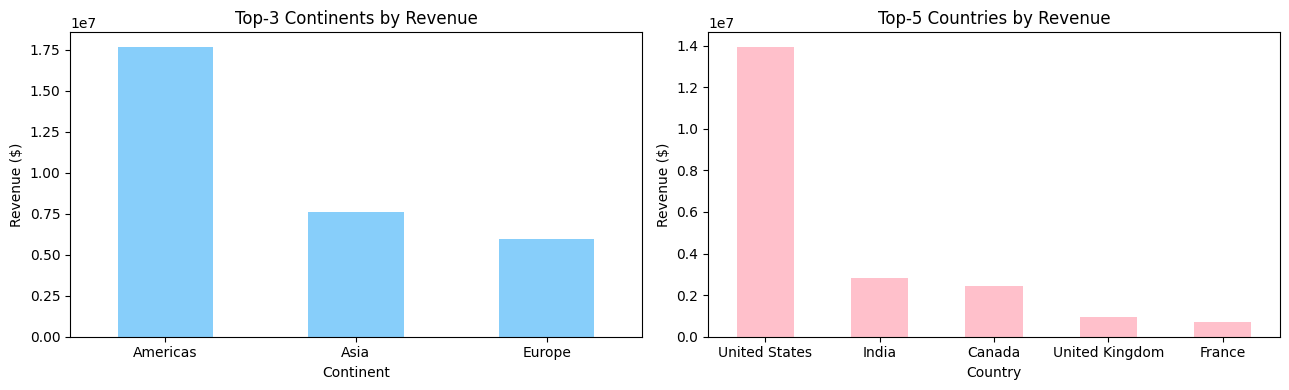

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

top3_continents_revenue["revenue"].plot(kind="bar", ax=axes[0], color="lightskyblue")
axes[0].set_title("Top-3 Continents by Revenue")
axes[0].set_xlabel("Continent")
axes[0].set_ylabel("Revenue ($)")
axes[0].tick_params(axis="x", rotation=0)

top5_countries_revenue["revenue"].plot(kind="bar", ax=axes[1], color="pink")
axes[1].set_title("Top-5 Countries by Revenue")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Revenue ($)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Both rankings — by revenue and by order count — produce the exact same top-3 continents in the exact same order: **Americas** (55.25% of revenue, 55.32% of orders), **Asia** (23.78% / 23.70%), and **Europe** (18.56% / 18.67%). Together these three continents account for **97.59%** of total revenue, leaving Africa and Oceania with a negligible combined share — a strong geographic concentration. At the country level, the picture is even more concentrated: the **United States alone generates 43.6% of total revenue** (13.94 million USD of 31.97 million USD), more than three times the next-largest market, India (8.8%). This level of dependency on a single country is a notable business risk worth flagging — any disruption in the US market would have an outsized impact on overall revenue.

## 3.2 Top-10 Product Categories by Total Sales

In [ ]:
category_summary = purchased.groupby("product_category").agg(
    revenue=("product_price", "sum"),
    orders=("session_id", "count")
).sort_values("revenue", ascending=False)
category_summary["revenue_share_%"] = (category_summary["revenue"] / total_revenue * 100).round(2)

top10_categories = category_summary.head(10)
top10_categories

,revenue,orders,revenue_share_%
product_category,,,
Sofas & armchairs,8388254.5,4301,26.24
Chairs,6147748.8,5952,19.23
Beds,4919725.0,2926,15.39
Bookcases & shelving units,3640818.1,7630,11.39
Cabinets & cupboards,2336499.5,2318,7.31
Outdoor furniture,2142222.2,2229,6.70
Tables & desks,1790307.5,2941,5.60
Chests of drawers & drawer units,906562.5,1452,2.84
Bar furniture,735503.0,1092,2.30


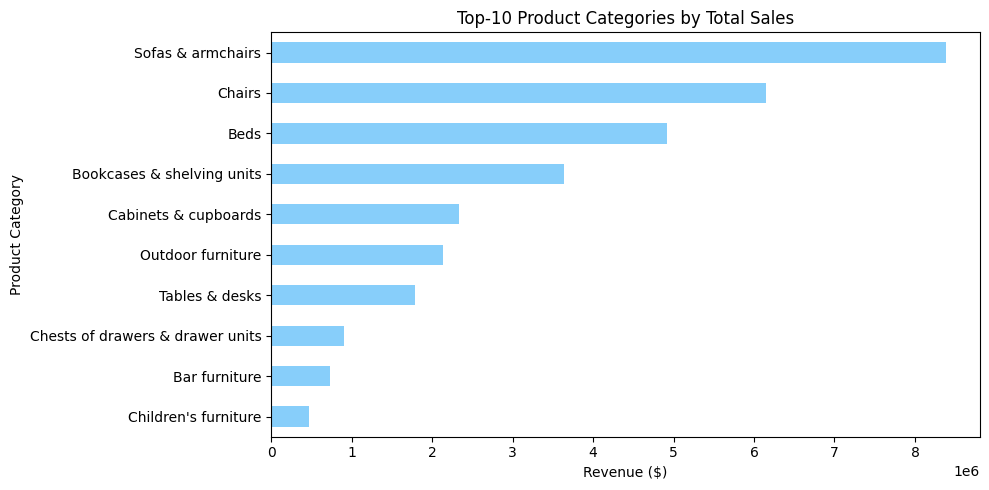

In [ ]:
plt.figure(figsize=(10, 5))
top10_categories["revenue"].sort_values().plot(kind="barh", color="lightskyblue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product Category")
plt.title("Top-10 Product Categories by Total Sales")
plt.tight_layout()
plt.show()

Revenue is fairly concentrated at the top: **Sofas & armchairs** (26.24%), **Chairs** (19.23%), and **Beds** (15.39%) together account for **60.86%** of total revenue, while the remaining seven categories in the top 10 share the rest more thinly. A notable divergence appears with **Bookcases & shelving units**: it has the highest order count of any category (7,630 orders — more than any other category, including the revenue leader), yet ranks only 4th in revenue (11.39%). Dividing revenue by orders confirms this is a high-volume, lower-value item (~ 477 USD average order value) compared to Sofas & armchairs (~ 1,950 USD average order value) — a classic "popular but not the most profitable" pattern, distinct from what drives the top of the revenue ranking.

## 3.3 Top-10 Categories in the Leading Country — Does the Picture Change?

In [ ]:
top_country = top5_countries_revenue.index[0]
purchased_top_country = purchased[purchased["country"] == top_country]

top10_categories_country = purchased_top_country.groupby("product_category").agg(
    revenue=("product_price", "sum"),
    orders=("session_id", "count")
).sort_values("revenue", ascending=False).head(10)

comparison = pd.DataFrame({
    "overall_rank": range(1, len(top10_categories) + 1),
    "overall_category": top10_categories.index,
    f"{top_country}_rank": range(1, len(top10_categories_country) + 1),
    f"{top_country}_category": top10_categories_country.index
})
comparison

,overall_rank,overall_category,United States_rank,United States_category
0,1,Sofas & armchairs,1,Sofas & armchairs
1,2,Chairs,2,Chairs
2,3,Beds,3,Beds
3,4,Bookcases & shelving units,4,Bookcases & shelving units
4,5,Cabinets & cupboards,5,Cabinets & cupboards
5,6,Outdoor furniture,6,Outdoor furniture
6,7,Tables & desks,7,Tables & desks
7,8,Chests of drawers & drawer units,8,Chests of drawers & drawer units
8,9,Bar furniture,9,Bar furniture
9,10,Children's furniture,10,Children's furniture


The United States — the single largest market by revenue — mirrors the overall top-10 category ranking **exactly**, rank for rank, from Sofas & armchairs down to Children's furniture. This is not a coincidence: since the US alone contributes 43.6% of total revenue, it effectively drives the global category pattern rather than diverging from it. In other words, "global" trends in this dataset are, to a large extent, a reflection of US buying behavior specifically.

## 3.4 Sales by Device Type and Model (% of Total Sales)

In [ ]:
device_summary = purchased.groupby("device_type")["product_price"].sum().sort_values(ascending=False)
device_pct = (device_summary / total_revenue * 100).round(2)

model_summary = purchased.groupby("mobile_model")["product_price"].sum().sort_values(ascending=False)
model_pct = (model_summary / total_revenue * 100).round(2)

print("Sales share by device type:")
display(device_pct)
print("\nSales share by top-10 device/model (includes \"<Other>\" as an aggregate bucket):")
display(model_pct.head(10))

Sales share by device type:


,product_price
device_type,
desktop,59.00
mobile,38.73
tablet,2.26



Sales share by top-10 device/model (includes "<Other>" as an aggregate bucket):


,product_price
mobile_model,
Chrome,27.84
<Other>,20.44
Safari,20.30
iPhone,20.08
ChromeBook,5.73
Edge,2.18
iPad,1.40
Firefox,1.32
Pixel 4 XL,0.37


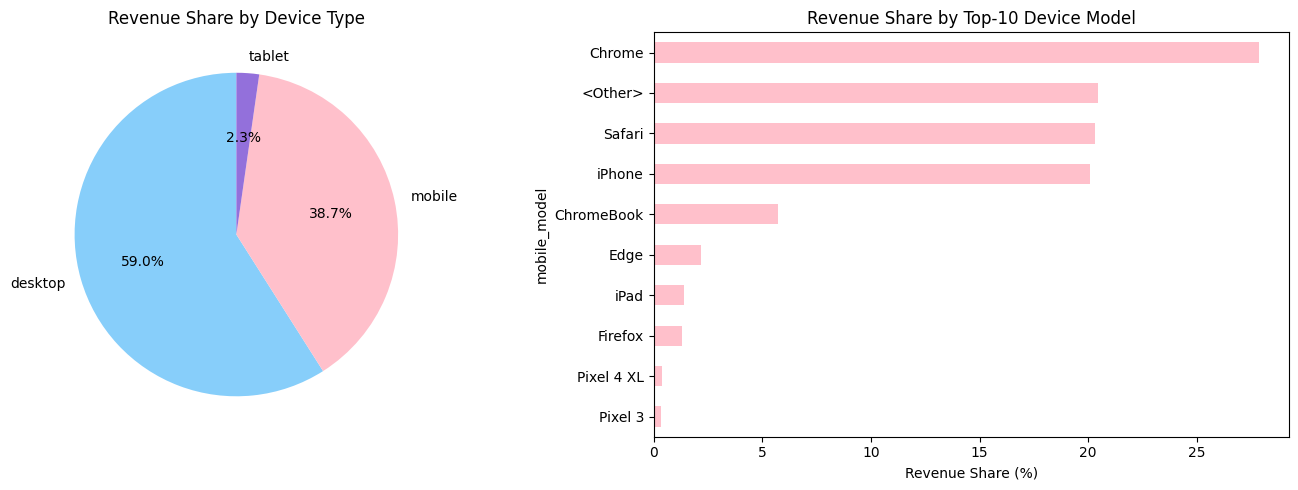

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(device_pct, labels=device_pct.index, autopct="%1.1f%%",
            colors=["lightskyblue", "pink", "mediumpurple"], startangle=90)
axes[0].set_title("Revenue Share by Device Type")

model_pct.head(10).sort_values().plot(kind="barh", ax=axes[1], color="pink")
axes[1].set_xlabel("Revenue Share (%)")
axes[1].set_title("Revenue Share by Top-10 Device Model")

plt.tight_layout()
plt.show()

Desktop is the dominant device type by revenue (**59.00%**), followed by mobile (**38.73%**) and tablet (**2.26%**). One structural nuance worth flagging in the underlying data: the `mobile_model` field mixes two different concepts depending on device type — for desktop sessions it records the **browser name** (Chrome, Safari, Edge, Firefox), while for mobile sessions it records the **device model** (iPhone, Pixel 4 XL, Pixel 3). This is a source-data characteristic rather than an analysis error, but it means the "top device model" ranking should be read as a mixed browser/device breakdown, not a pure hardware comparison.

## 3.5 Sales by Traffic Source (% of Total Sales)

In [ ]:
channel_summary = purchased.groupby("traffic_channel")["product_price"].sum().sort_values(ascending=False)
channel_pct = (channel_summary / total_revenue * 100).round(2)
channel_pct

,product_price
traffic_channel,
Organic Search,35.76
Paid Search,26.62
Direct,23.44
Social Search,7.92
Undefined,6.26


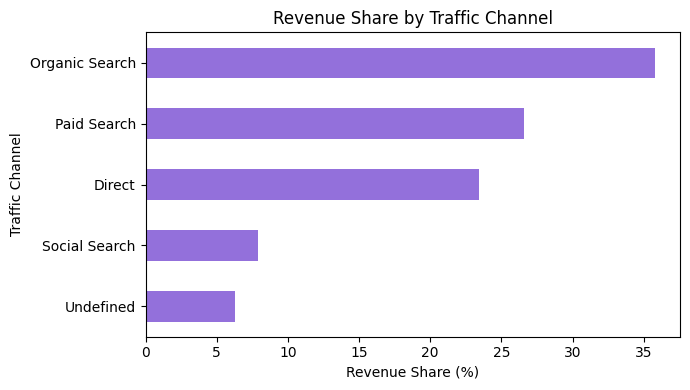

In [ ]:
plt.figure(figsize=(7, 4))
channel_pct.sort_values().plot(kind="barh", color="mediumpurple")
plt.xlabel("Revenue Share (%)")
plt.ylabel("Traffic Channel")
plt.title("Revenue Share by Traffic Channel")
plt.tight_layout()
plt.show()

Organic Search is the leading revenue driver at **35.76%** of total sales, ahead of Paid Search (**26.62%**) and Direct traffic (**23.44%**), with Social Search (7.92%) and Undefined traffic (6.26%) trailing well behind. Notably, more than a third of all revenue is generated without any paid acquisition cost, which points to a reasonably strong organic/brand presence rather than heavy reliance on paid channels.

## 3.6 Email Verification Rate Among Registered Users

In [ ]:
registered = data[data["is_registered"]]
verified_share = (registered["is_email_verified"] == 1).mean() * 100
print(f"Registered users: {registered["account_id"].nunique():,}")
print(f"Share with verified email: {verified_share:.2f}%")

Registered users: 27,945
Share with verified email: 71.70%


**71.70%** of the 27,945 registered users have verified their email address. This leaves a meaningful minority — nearly 3 in 10 registrants — unverified, which is worth monitoring as a potential drop-off point in the onboarding funnel, though a rate above 70% generally reflects a reasonably healthy registration flow.

## 3.7 Unsubscribe Rate Among Registered Users

In [ ]:
unsubscribed_share = (registered["is_unsubscribed"] == 1).mean() * 100
print(f"Share of registered users who unsubscribed: {unsubscribed_share:.2f}%")

Share of registered users who unsubscribed: 16.94%


**16.94%** of registered users have unsubscribed from the mailing list. This is a moderate churn rate — not alarmingly high, but high enough (roughly 1 in 6 subscribers) to warrant a closer look at email frequency or content relevance in a future iteration of this analysis.

## 3.8 Sales Behavior: Unsubscribed vs. Still Subscribed

In [ ]:
subscription_behavior = registered.groupby("is_unsubscribed").apply(
    lambda g: pd.Series({
        "sessions": len(g),
        "purchased_sessions": (g["product_category"] != "No purchase").sum(),
        "conversion_rate_%": (g["product_category"] != "No purchase").mean() * 100,
        "total_revenue": g.loc[g["product_category"] != "No purchase", "product_price"].sum(),
        "avg_order_value": g.loc[g["product_category"] != "No purchase", "product_price"].mean()
    }),
    include_groups=False
)
subscription_behavior.index = subscription_behavior.index.map({0: "Still subscribed", 1: "Unsubscribed"})
subscription_behavior

,sessions,purchased_sessions,conversion_rate_%,total_revenue,avg_order_value
is_unsubscribed,,,,,
Still subscribed,23210.0,2334.0,10.056010,2150796.9,921.506812
Unsubscribed,4735.0,447.0,9.440338,431721.6,965.820134


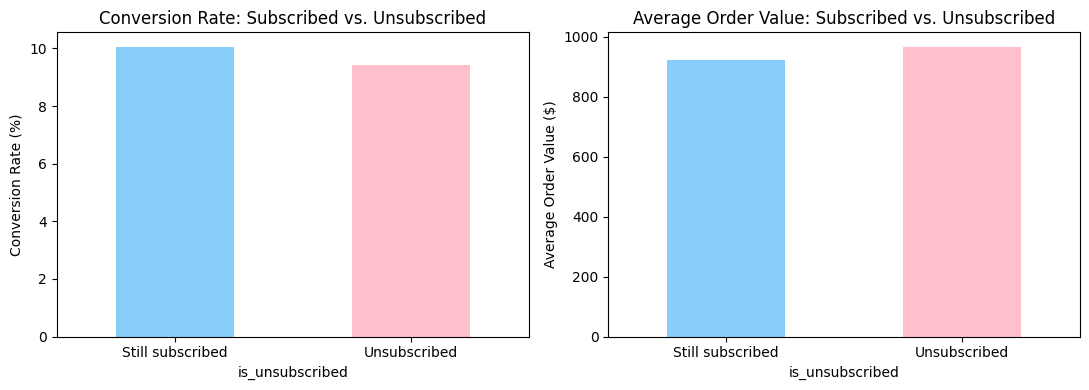

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

subscription_behavior["conversion_rate_%"].plot(kind="bar", ax=axes[0], color=["lightskyblue", "pink"])
axes[0].set_title("Conversion Rate: Subscribed vs. Unsubscribed")
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].tick_params(axis="x", rotation=0)

subscription_behavior["avg_order_value"].plot(kind="bar", ax=axes[1], color=["lightskyblue", "pink"])
axes[1].set_title("Average Order Value: Subscribed vs. Unsubscribed")
axes[1].set_ylabel("Average Order Value ($)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Comparing subscribed and unsubscribed users reveals a counter-intuitive pattern: conversion rate is nearly identical between the two groups (10.06% for still-subscribed vs. 9.44% for unsubscribed users), but **average order value is actually higher among unsubscribed users** (965.82 USD vs. 921.51 USD). In other words, unsubscribing from marketing emails does not appear to reduce a customer's willingness to spend — if anything, this sample shows the opposite direction. However, the gap is modest relative to the sample sizes involved (447 vs. 2,334 purchasing sessions), so this descriptive comparison should not be read as a confirmed effect; the "Statistical analysis of group differences" section later in this project will test whether either difference (conversion rate or order value) is statistically significant.

## 3.9 Countries with the Most Registered Users

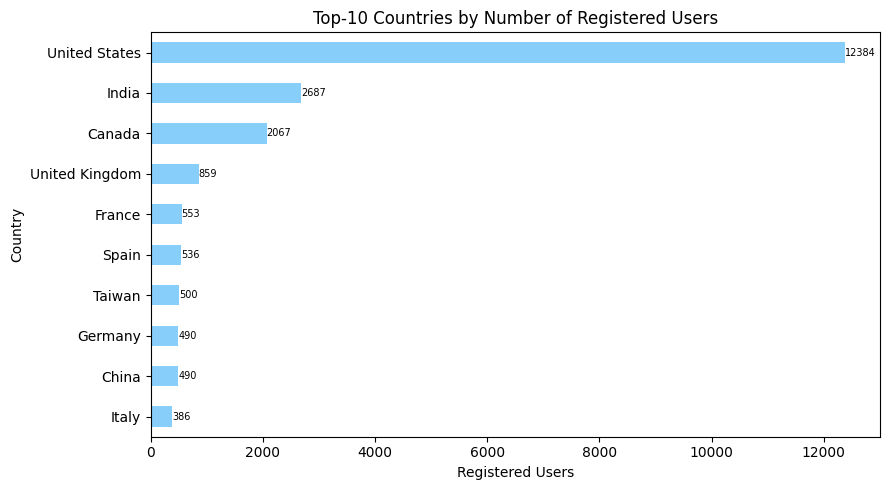

In [ ]:
top10_countries_registered = registered.groupby("country")["account_id"].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
ax = top10_countries_registered.sort_values().plot(kind="barh", color="lightskyblue")
plt.xlabel("Registered Users")
plt.ylabel("Country")
plt.title("Top-10 Countries by Number of Registered Users")
plt.tight_layout()

# Add data labels
for bar in ax.patches:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.0f}",
        ha="left",
        va="center",
        color="black",
        fontsize=7,
    )

plt.show()

The top-10 countries by registered users — **United States (12,384), India (2,687), Canada (2,067), United Kingdom (859), France (553)**, followed by Spain, Taiwan, Germany, China, and Italy — match the top-5 countries by revenue from Section 3.1 **exactly, in the same order**. This confirms that registration and spending are concentrated in the same markets rather than being independent behaviors: the countries that generate the most revenue are also the ones where the most users choose to create an account, reinforcing the case for prioritizing these five markets in any registration-driven growth strategy.

## 3.10 Additional Insights

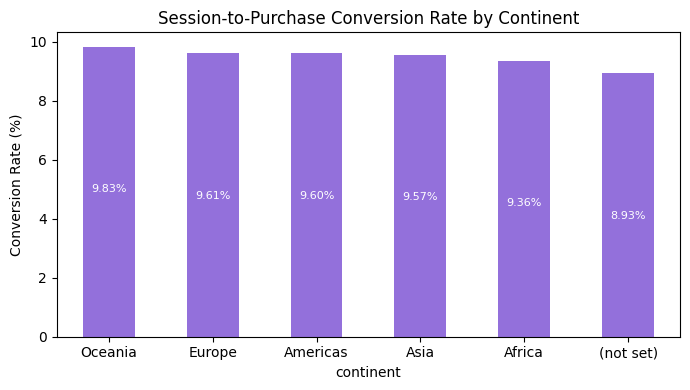

In [ ]:
# Insight 1: Conversion rate by continent — reveals efficiency, not just volume
conversion_by_continent = data.groupby("continent").apply(
    lambda g: (g["product_category"] != "No purchase").mean() * 100,
    include_groups=False
).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
ax = conversion_by_continent.plot(kind="bar", color="mediumpurple")
plt.ylabel("Conversion Rate (%)")
plt.title("Session-to-Purchase Conversion Rate by Continent")
plt.xticks(rotation=0)
plt.tight_layout()

# Add data labels
for bar in ax.patches:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 5,          # small offset above the bar
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        color="white",
        fontsize=8,
    )

plt.show()

Conversion rate is remarkably stable across continents, ranging narrowly from **8.93% to 9.83%** — a spread of less than one percentage point. Notably, **Oceania has the highest conversion rate (9.83%)**, not Americas (9.60%), even though Americas generates by far the most revenue (Section 3.1). This confirms the hypothesis raised earlier: Americas' revenue lead is driven primarily by **traffic volume**, not by converting visitors more efficiently — a smaller market like Oceania is actually more effective at turning sessions into purchases on a like-for-like basis. The lowest bar, labeled **"(not set)"** (8.93%), reflects sessions with a missing/unclassified continent value in the source data rather than a real geographic segment, and should be treated as a data-quality artifact rather than a genuine underperforming region.

In [ ]:
# Insight 2: Registered vs. anonymous sessions — do registered users spend differently?
registration_behavior = data.groupby("is_registered").apply(
    lambda g: pd.Series({
        "sessions": len(g),
        "conversion_rate_%": (g["product_category"] != "No purchase").mean() * 100,
        "avg_order_value": g.loc[g["product_category"] != "No purchase", "product_price"].mean()
    }),
    include_groups=False
)
registration_behavior.index = registration_behavior.index.map({False: "Anonymous", True: "Registered"})
registration_behavior

,sessions,conversion_rate_%,avg_order_value
is_registered,,,
Anonymous,321600.0,9.563744,955.529232
Registered,27945.0,9.951691,928.629450


Registered and anonymous sessions convert at nearly the same rate (**9.95%** registered vs. **9.56%** anonymous) and spend similarly per order (**928.63 USD** vs. **955.53 USD**) — registered users do not show a meaningfully higher conversion rate or order value than anonymous visitors in this dataset. This suggests that, on a per-session basis, the value of registration to the business may lie more in retention and repeat-visit potential (which this single-session-level view cannot capture) than in an immediate lift in purchase behavior.

# 4. Sales Dynamics Over Time

This section examines how revenue behaves across the 92-day observation window (2020-11-01 to 2021-01-31), first as a single overall trend, then broken down by continent, traffic channel, and device type to see whether different segments follow the same pattern or diverge from it.

## 4.1 Overall Daily Sales Dynamics

Days covered: 92
Average daily revenue: $347,518.82
Min: $0.00 on 2021-01-28
Max: $680,509.50 on 2020-12-08


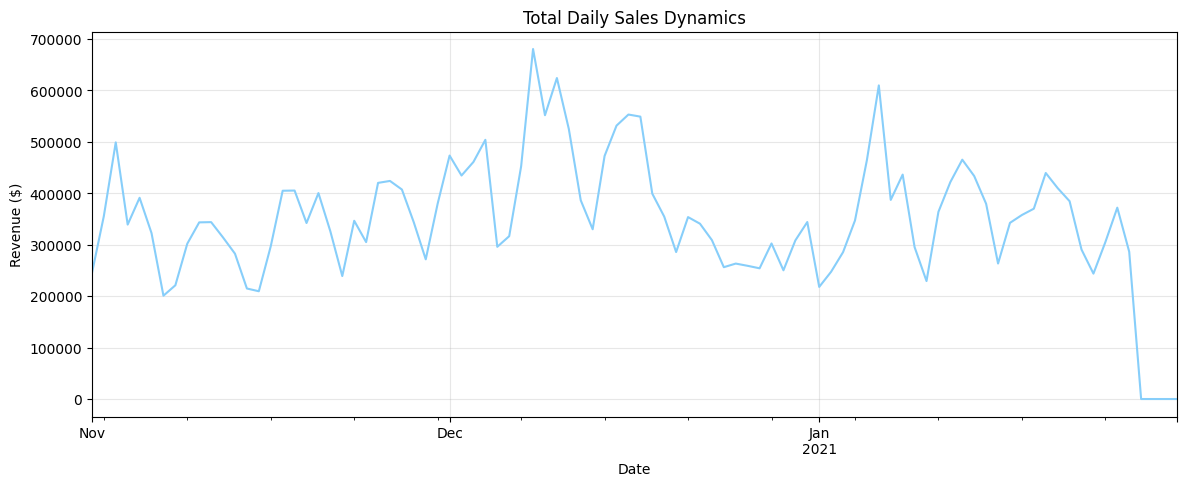

In [ ]:
daily_sales = data.groupby("session_date")["product_price"].sum()

print(f"Days covered: {len(daily_sales)}")
print(f"Average daily revenue: ${daily_sales.mean():,.2f}")
print(f"Min: ${daily_sales.min():,.2f} on {daily_sales.idxmin().date()}")
print(f"Max: ${daily_sales.max():,.2f} on {daily_sales.idxmax().date()}")

plt.figure(figsize=(14, 5))
daily_sales.plot(kind="line", color="lightskyblue")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.title("Total Daily Sales Dynamics")
plt.grid(alpha=0.3)
plt.show()

Average daily revenue across the period is **347,518.82 USD**. The lowest point is **0.00 USD on 2021-01-28** — a single day with zero recorded revenue inside an otherwise active 92-day window is unusual enough to flag as a likely data gap (e.g. a tracking or pipeline issue for that date) rather than a genuine zero-sales day, and is worth a quick follow-up check (e.g. whether session counts for that date are also unusually low) before treating it as a real business event. The highest point is **680,509.50 USD on 2020-12-08** — early-to-mid December, consistent with pre-holiday shopping season demand, roughly double the average daily revenue.

## 4.2 Is There Seasonality in Sales?

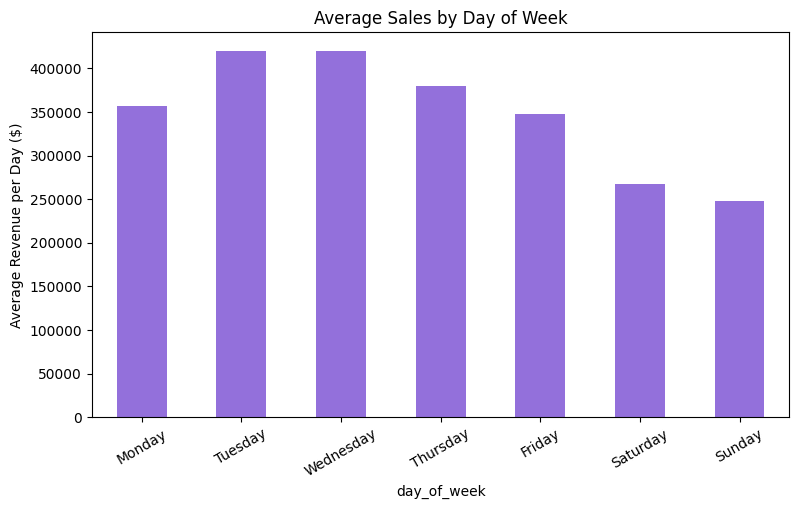

,0
day_of_week,
Monday,356637.723077
Tuesday,419808.915385
Wednesday,420503.300000
Thursday,379764.276923
Friday,347928.246154
Saturday,267537.761538
Sunday,248099.157143


In [ ]:
data["day_of_week"] = data["session_date"].dt.day_name()

# Order matters for a readable chart — Monday first, not alphabetical
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

avg_sales_by_day = data.groupby("day_of_week")["product_price"].sum() / data["session_date"].dt.date.nunique()
day_counts = data[data["day_of_week"].notna()].groupby("day_of_week")["session_date"].apply(lambda x: x.dt.date.nunique())

avg_sales_by_day = (data.groupby("day_of_week")["product_price"].sum() / day_counts).reindex(day_order)

plt.figure(figsize=(9, 5))
avg_sales_by_day.plot(kind="bar", color="mediumpurple")
plt.ylabel("Average Revenue per Day ($)")
plt.title("Average Sales by Day of Week")
plt.xticks(rotation=30)
plt.show()

avg_sales_by_day

With only 92 days of data, monthly or annual seasonality cannot be assessed (as already noted in Section 2), but a clear **weekly seasonality** pattern emerges. Average revenue peaks mid-week — **Wednesday (420,503 USD)** and **Tuesday (419,809 USD)** — and drops sharply on weekends, bottoming out on **Sunday (248,099 USD)**, roughly 41% lower than the Wednesday peak. Monday, Thursday, and Friday sit in between (347K USD - 380K USD). This is a consistent business-day-vs-weekend pattern typical of B2B-leaning or desk-based purchasing behavior, and it's a useful signal for scheduling promotions or campaigns around mid-week peaks rather than weekends.

## 4.3 Sales Dynamics by Continent (Americas, Asia, Europe)

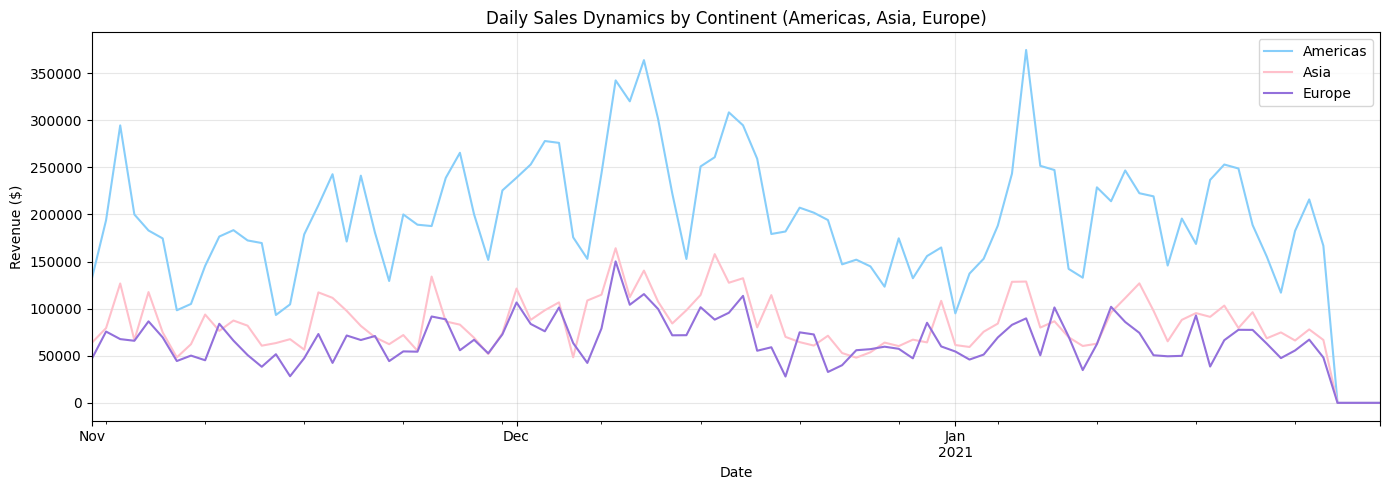

In [ ]:
asia_sales = data[data["continent"] == "Asia"].groupby("session_date")["product_price"].sum()
americas_sales = data[data["continent"] == "Americas"].groupby("session_date")["product_price"].sum()
europe_sales = data[data["continent"] == "Europe"].groupby("session_date")["product_price"].sum()

plt.figure(figsize=(14, 5))

americas_sales.plot(kind="line", color="lightskyblue", label="Americas")
asia_sales.plot(kind="line", color="pink", label="Asia")
europe_sales.plot(kind="line", color="mediumpurple", label="Europe")

plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.title("Daily Sales Dynamics by Continent (Americas, Asia, Europe)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Americas (light blue) sits clearly above both Asia (pink) and Europe (purple) for nearly the entire period, consistent with its 55.25% revenue share from Section 3.1 — and the gap is visible as a consistent gap in the line chart, not just an average. Americas is also by far the most **volatile** line, with sharp mid-week peaks reaching 300K USD - 380K USD, including the single highest point in the whole dataset around early January — well above its typical 150K USD - 250K USD range. Asia and Europe move in a much narrower band (50K USD - 150K USD) and are close to each other, occasionally crossing, with Asia usually slightly ahead. All three lines converge toward **zero at the very end of the period** — this lines up exactly with the anomalous zero-revenue day flagged in Section 4.1 (2021-01-28), and the fact that *all three continents* drop together at the same point is further evidence this is a **data gap affecting the whole dataset**, not a real regional slowdown.

## 4.4 Sales Dynamics by Traffic Channel

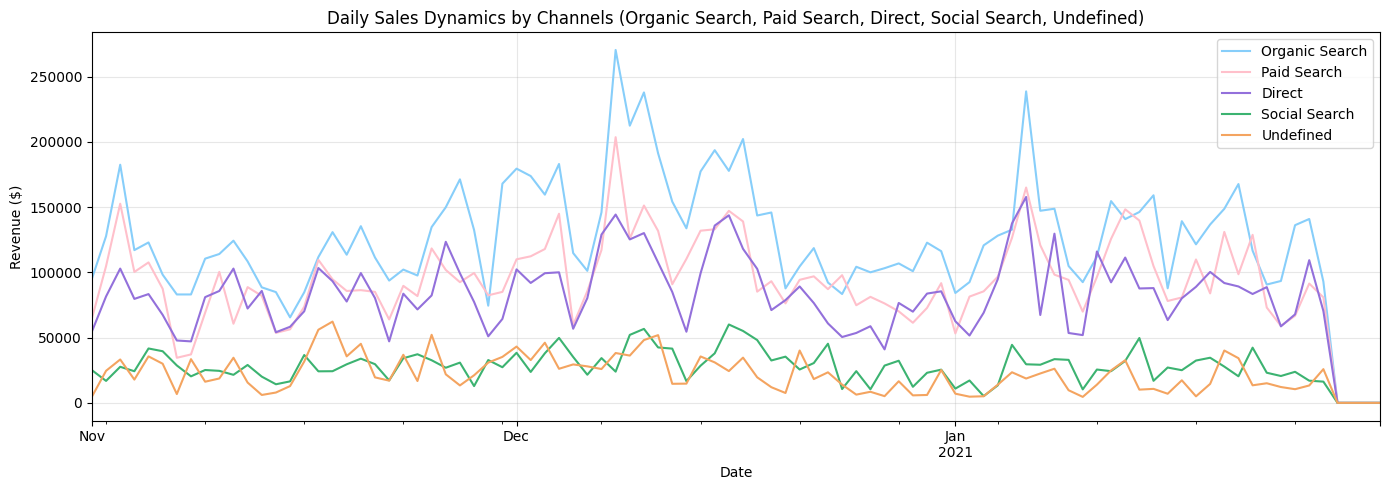

In [ ]:
organic_sales = data[data["traffic_channel"] == "Organic Search"].groupby("session_date")["product_price"].sum()
paid_sales = data[data["traffic_channel"] == "Paid Search"].groupby("session_date")["product_price"].sum()
direct_sales = data[data["traffic_channel"] == "Direct"].groupby("session_date")["product_price"].sum()
social_sales = data[data["traffic_channel"] == "Social Search"].groupby("session_date")["product_price"].sum()
undefined_sales = data[data["traffic_channel"] == "Undefined"].groupby("session_date")["product_price"].sum()

plt.figure(figsize=(14, 5))

organic_sales.plot(kind="line", color="lightskyblue", label="Organic Search")
paid_sales.plot(kind="line", color="pink", label="Paid Search")
direct_sales.plot(kind="line", color="mediumpurple", label="Direct")
social_sales.plot(kind="line", color="mediumseagreen", label="Social Search")
undefined_sales.plot(kind="line", color="sandybrown", label="Undefined")

plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.title("Daily Sales Dynamics by Channels (Organic Search, Paid Search, Direct, Social Search, Undefined)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Organic Search (light blue) leads throughout almost the entire window, matching its 35.76% revenue share from Section 3.5, and shows the same sharp, spiky pattern as the Americas line in 4.3 — strongly suggesting the Organic Search peaks and the Americas peaks are largely the same underlying sessions. Paid Search (pink) and Direct (purple) track each other fairly closely in a lower band, with Paid Search occasionally spiking above Organic Search on specific days — a pattern consistent with paid acquisition, where campaigns create short, concentrated bursts rather than the steadier, broader pull of organic traffic. Social Search (green) and Undefined (orange) sit well below the other three, both fluctuating narrowly under 50K USD - 75K USD, confirming they are minor contributors rather than volatile or erratic outliers. As with the continent breakdown, **all five channels drop to near zero simultaneously** at the end of the period, reinforcing that the anomaly identified in 4.1 is a dataset-wide gap rather than a channel-specific drop.

## 4.5 Sales Dynamics by Device Type

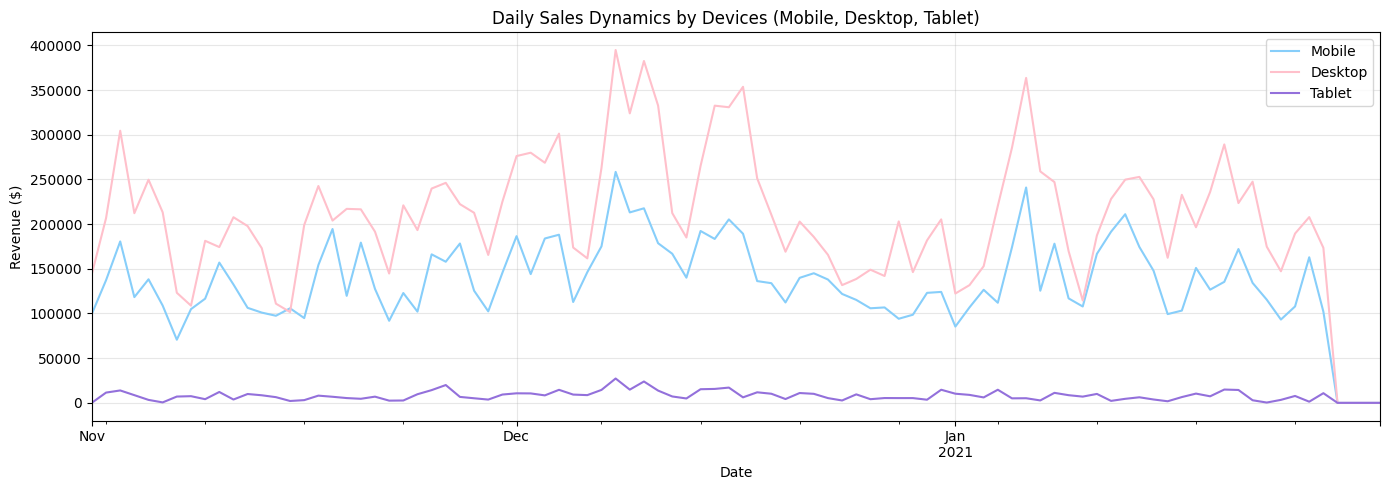

In [ ]:
mobile_sales = data[data["device_type"] == "mobile"].groupby("session_date")["product_price"].sum()
desktop_sales = data[data["device_type"] == "desktop"].groupby("session_date")["product_price"].sum()
tablet_sales = data[data["device_type"] == "tablet"].groupby("session_date")["product_price"].sum()

plt.figure(figsize=(14, 5))

mobile_sales.plot(kind="line", color="lightskyblue", label="Mobile")
desktop_sales.plot(kind="line", color="pink", label="Desktop")
tablet_sales.plot(kind="line", color="mediumpurple", label="Tablet")

plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.title("Daily Sales Dynamics by Devices (Mobile, Desktop, Tablet)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Desktop (pink) is consistently above Mobile (light blue) for the entire period, matching its 59.00% revenue share from Section 3.4, and — importantly — desktop is also the line responsible for the two highest points in the whole dataset (around 2020-12-08 and again in early January), directly explaining the December peak identified in Section 4.1. Mobile follows a similar shape one tier below desktop (100K USD - 250K USD), suggesting mobile revenue rises and falls on largely the same days as desktop rather than having its own independent rhythm (e.g. no clear weekend mobile surge is visible). Tablet (purple) is essentially flat near zero throughout, consistent with its minimal 2.26% share — it contributes so little that it barely registers as a visible line on this scale. All three device types dip together at the very end, consistent with the dataset-wide gap already noted.

## 4.6 Conclusions from Sales Dynamics Visualizations

- Revenue follows a clear **weekly cycle** (mid-week peak, weekend trough) rather than a smooth trend — any forecasting or staffing decisions should account for this rhythm rather than assuming flat daily demand.
- The **single zero-revenue day (2021-01-28)** is confirmed across *every* segment breakdown (continent, channel, device) — all lines converge to zero simultaneously, which strongly points to a **data pipeline gap on that date** rather than a real, isolated business event, and should be verified against raw session counts before being reported as an actual sales collapse.
- The **December/early-January revenue peaks** identified in 4.1 are driven predominantly by the same underlying segment combination: **Americas + Organic Search + Desktop** all peak on the same dates, rather than each spike being driven by a different part of the business. This convergence is a useful signal — the business's revenue volatility is concentrated in one segment combination, which is worth watching if that combination weakens.
- Beyond the shared spikes, each segment's *relative* ranking from Section 3 holds steady throughout the whole period rather than shifting over time (e.g. Americas never gets overtaken by Asia or Europe, Desktop is never overtaken by Mobile) — the geographic/channel/device concentration described in Section 3 is a stable structural feature of the business, not just a snapshot average.

# 5. Pivot Tables

Four pivot tables cutting the data along different combinations of dimensions — two required by the assignment (traffic channel × device, and product category × country), plus two additional cuts (device model × continent, and product category × registration status) chosen to surface patterns not visible in the single-dimension breakdowns in Section 3.

## 5.1 Session Count by Traffic Channel and Device Type

In [ ]:
known_channels = data[data["traffic_channel"] != "Undefined"]
pivot_table_session = pd.pivot_table(known_channels, values="session_id", index="traffic_channel", columns="device_type", aggfunc="count", fill_value=0)
pivot_table_session


device_type,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638


Desktop leads session count in every single traffic channel, consistent with its 59% revenue share from Section 3.4. More interesting is that the **mobile share is remarkably stable across channels** — roughly 39% of sessions are mobile for Direct (39.0%), Organic Search (39.4%), Paid Search (39.3%), and Social Search (39.4%) alike. This means device choice appears to be an independent user preference rather than something driven by how the visitor arrived at the site — no channel is disproportionately more "mobile-heavy" or "desktop-heavy" than the others. `Undefined` traffic was excluded from this table since it represents an unclassified channel, not a real acquisition source.

## 5.2 Total Sales by Product Category (Top-10) and Country (Top-5)

In [ ]:
top10_category_list = top10_categories.index.tolist()
top5_country_list = top5_countries_revenue.index.tolist()

pivot_data = purchased[
    purchased["product_category"].isin(top10_category_list) &
    purchased["country"].isin(top5_country_list)]

sales_pivot = pd.pivot_table(pivot_data, index="product_category", columns="country", values="product_price", aggfunc="sum", fill_value=0)

sales_pivot

country,Canada,France,India,United Kingdom,United States
product_category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


The United States dominates every category cell in this table, in line with its 43.6% overall revenue share — for example, it accounts for 66.1% of Sofas & armchairs revenue and 69.9% of Bar furniture revenue among these five countries, so its dominance is fairly uniform rather than concentrated in specific categories. The country ranking (US > India > Canada > UK > France) generally holds category-by-category too, with one notable exception: **Outdoor furniture is the one category where Canada outsells India** (185,323 USD vs. 162,289 USD), reversing their usual order. Every other category in this table follows the expected overall ranking, which makes this a genuine, localized product-preference signal rather than noise.

## 5.3 Session Count by Device Model and Continent

In [ ]:
known_continents = data[data["continent"] != "(not set)"]
pivot_table_session_cont = pd.pivot_table(known_continents, values="session_id", index="mobile_model", columns="continent", aggfunc="count", fill_value=0)
pivot_table_session_cont

continent,Africa,Americas,Asia,Europe,Oceania
mobile_model,,,,,
<Other>,697,39300,16908,12999,768
Chrome,996,53940,23007,18105,1000
ChromeBook,183,10509,4451,3648,248
Edge,98,4403,1905,1399,78
Firefox,56,2748,1135,873,52
Pixel 3,5,548,246,211,22
Pixel 4 XL,8,672,326,227,13
Safari,751,38982,16837,13338,781
iPad,42,2754,1241,996,51


This breakdown confirms the browser/device-model conflation noted in Section 3.4 (desktop rows record browser names like Chrome/Safari, mobile rows record device models like iPhone) applies uniformly across every continent — no continent shows a distinctly different browser or device mix. Chrome is the single most common entry everywhere, and Safari/iPhone counts track each other closely on every continent (as expected, since iPhone's default browser is Safari). `(not set)` continent values were excluded here for the same reason as elsewhere in this project — they represent missing classification, not a real geography.

## 5.4 Total Sales by Product Category and Registration Status

In [ ]:
category_registration_pivot_top10 = pd.pivot_table(
    purchased[purchased["product_category"].isin(top10_category_list)],
    index="product_category",
    columns="is_registered",
    values="product_price",
    aggfunc="sum",
    fill_value=0)
category_registration_pivot_top10.columns = category_registration_pivot_top10.columns.map({True: "Registered", False: "Anonymous"})
category_registration_pivot_top10

is_registered,Anonymous,Registered
product_category,,
Bar furniture,684489.0,51014.0
Beds,4525020.0,394705.0
Bookcases & shelving units,3365308.5,275509.6
Cabinets & cupboards,2120630.0,215869.5
Chairs,5607792.6,539956.2
Chests of drawers & drawer units,848574.5,57988.0
Children's furniture,417462.0,50235.0
Outdoor furniture,1998528.0,143694.2
Sofas & armchairs,7727798.5,660456.0


Across the top-10 categories, registered users contribute **8.08%** of revenue on average — closely matching the 7.99% registered-session share from Section 2, and consistent with the Section 3.10 finding that registered and anonymous sessions convert and spend similarly overall. However, this table reveals category-level variation that the single overall figure hides: **Children's furniture stands out**, with registered users contributing **10.74%** of its revenue — the highest of any category — plausibly reflecting that registered, likely repeat customers are more often parents making considered purchases for their children, rather than one-off anonymous browsing. At the other end, **Bar furniture (6.94%) and Outdoor furniture (6.71%)** see the lowest registered contribution, suggesting these are more often impulse or one-time purchases.

## 5.5 Conclusions from Pivot Tables

- Device preference (desktop vs. mobile) is **consistent across acquisition channels** (~39% mobile everywhere) — marketing channel choice does not appear to influence which device a visitor buys on.
- Country dominance in the product-category breakdown is **broad rather than category-specific** — the US leads virtually every category by a similar margin, with **Outdoor furniture** as the one clear exception where Canada overtakes India.
- The device/browser field's structural quirk (Section 3.4) is confirmed to be a **global, not regional, pattern** — every continent shows the same browser-vs-model mix.
- Registration status has a **modest but real effect at the category level**: children's items show the highest registered-user contribution, while bar and outdoor furniture show the lowest — a more nuanced picture than the near-identical overall conversion rates suggested in Section 3.10.

# 6. Statistical Analysis of Relationships

This section tests whether daily revenue across different dimensions — session volume, continents, traffic channels, and product categories — moves together, using Pearson correlation with significance testing. All correlations are computed on **daily aggregates** (one value per date), so a "strong correlation" here means two series tend to rise and fall on the *same days*, not that they are related at the individual-transaction level.

**A note on multiple comparisons:** whenever more than one pair is tested at once, the chance of finding a "significant" result purely by chance increases with the number of tests. A Bonferroni-adjusted threshold (`0.05 / number of tests`) is reported alongside the standard `0.05` for each multi-pair block below, to confirm findings hold up even under a stricter standard.

## 6.1 Do Session Count and Total Sales Correlate by Date?

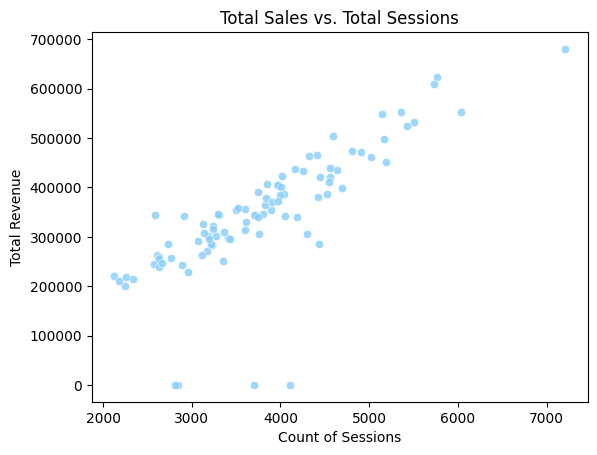

In [ ]:
session_by_date = data.groupby("session_date")["session_id"].count()
sales_by_date = data.groupby("session_date")["product_price"].sum()

sns.scatterplot(x = session_by_date, y = sales_by_date, color="lightskyblue", alpha=0.8)
plt.title("Total Sales vs. Total Sessions")
plt.xlabel("Count of Sessions")
plt.ylabel("Total Revenue")
plt.show()

In [ ]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(session_by_date, sales_by_date)

print(f"Correlation coefficient: {correlation:.4f}")
print(f"P-value: {p_value}")

Correlation coefficient: 0.7911
P-value: 6.483532312080735e-21


Session count and total daily revenue show a **strong positive correlation** (r = 0.79, p = 6.48 × 10⁻²¹), meaning days with more sessions are reliably days with more revenue — as expected for an e-commerce site, since more visits create more purchase opportunities. With p far below 0.001, this relationship is statistically significant beyond any reasonable doubt; a correlation this strong occurring by chance in 92 days of data is effectively impossible.

## 6.2 Do Sales Correlate Across Continents? (Top-3: Americas, Asia, Europe)

In [ ]:
corr_americas = data[data["continent"]=="Americas"].groupby("session_date")["product_price"].sum()
corr_asia = data[data["continent"]=="Asia"].groupby("session_date")["product_price"].sum()
corr_europe = data[data["continent"]=="Europe"].groupby("session_date")["product_price"].sum()

correlation1, p_value1 = pearsonr(corr_americas, corr_asia)
correlation2, p_value2 = pearsonr(corr_americas, corr_europe)
correlation3, p_value3 = pearsonr(corr_europe, corr_asia)

print(f"P-value for Americas and Asia: {p_value1}")
print(f"Correlation coefficient for Americas and Asia: {correlation1:.4f}")
print(f"P-value for Americas and Europe: {p_value2}")
print(f"Correlation coefficient for Americas and Europe: {correlation2:.4f}")
print(f"P-value for Asia and Europe: {p_value3}")
print(f"Correlation coefficient for Asia and Europe: {correlation3:.4f}")

P-value for Americas and Asia: 5.409189396197475e-21
Correlation coefficient for Americas and Asia: 0.7920
P-value for Americas and Europe: 2.6714492240629956e-19
Correlation coefficient for Americas and Europe: 0.7706
P-value for Asia and Europe: 3.8649460090531196e-19
Correlation coefficient for Asia and Europe: 0.7684


All three continent pairs show a **strong positive correlation**, all clustered tightly around **r ≈ 0.77-0.79**:

| Pair | r | p-value |
|---|---|---|
| Americas – Asia | 0.7920 | 5.41 × 10⁻²¹ |
| Americas – Europe | 0.7706 | 2.67 × 10⁻¹⁹ |
| Asia – Europe | 0.7684 | 3.86 × 10⁻¹⁹ |

With 3 comparisons, the Bonferroni-adjusted threshold is 0.05 / 3 = **0.0167** — every p-value here is many orders of magnitude below that, so all three relationships remain highly significant even under this stricter standard. This confirms and quantifies the pattern first observed visually in Section 4.3: continents don't move independently — they rise and fall together, almost certainly driven by a shared calendar effect (the same weekly cycle and holiday-season peak from Section 4 affecting every region simultaneously) rather than continent-specific dynamics.

## 6.3 Do Sales Correlate Across Traffic Channels?

In [ ]:
corr_social = data[data["traffic_channel"]=="Social Search"].groupby("session_date")["product_price"].sum()
corr_direct = data[data["traffic_channel"]=="Direct"].groupby("session_date")["product_price"].sum()
corr_paid = data[data["traffic_channel"]=="Paid Search"].groupby("session_date")["product_price"].sum()
corr_organic = data[data["traffic_channel"]=="Organic Search"].groupby("session_date")["product_price"].sum()

correlation4, p_value4 = pearsonr(corr_direct, corr_social)
correlation5, p_value5 = pearsonr(corr_social, corr_paid)
correlation6, p_value6 = pearsonr(corr_social, corr_organic)
correlation7, p_value7 = pearsonr(corr_direct, corr_paid)
correlation8, p_value8 = pearsonr(corr_direct, corr_organic)
correlation9, p_value9 = pearsonr(corr_paid, corr_organic)


print(f"P-value for Social Search and Direct: {p_value4}")
print(f"Correlation coefficient for Social Search and Direct: {correlation4:.4f}")
print(f"P-value for Social Search and Paid Search: {p_value5}")
print(f"Correlation coefficient for Social Search and Paid Search: {correlation5:.4f}")
print(f"P-value for Social Search and Organic Search: {p_value6}")
print(f"Correlation coefficient for Social Search and Organic Search: {correlation6:.4f}")
print(f"P-value for Direct and Paid Search: {p_value7}")
print(f"Correlation coefficient for Direct and Paid Search: {correlation7:.4f}")
print(f"P-value for Direct and Organic Search: {p_value8}")
print(f"Correlation coefficient for Direct and Organic Search: {correlation8:.4f}")
print(f"P-value for Paid Search and Organic Search: {p_value9}")
print(f"Correlation coefficient for Paid Search and Organic Search: {correlation9:.4f}")

P-value for Social Search and Direct: 1.831889246946262e-10
Correlation coefficient for Social Search and Direct: 0.6041
P-value for Social Search and Paid Search: 3.5322844619049755e-10
Correlation coefficient for Social Search and Paid Search: 0.5964
P-value for Social Search and Organic Search: 1.0661924301883206e-09
Correlation coefficient for Social Search and Organic Search: 0.5831
P-value for Direct and Paid Search: 5.896434878977516e-23
Correlation coefficient for Direct and Paid Search: 0.8141
P-value for Direct and Organic Search: 2.1904196603645366e-25
Correlation coefficient for Direct and Organic Search: 0.8378
P-value for Paid Search and Organic Search: 2.1420029219324783e-29
Correlation coefficient for Paid Search and Organic Search: 0.8701


With 4 channels (`Undefined` excluded, consistent with its treatment elsewhere in this project), there are 6 possible pairs:

| Pair | r | p-value |
|---|---|---|
| Paid Search – Organic Search | 0.8701 | 2.14 × 10⁻²⁹ |
| Direct – Organic Search | 0.8378 | 2.19 × 10⁻²⁵ |
| Direct – Paid Search | 0.8141 | 5.90 × 10⁻²³ |
| Direct – Social Search | 0.6041 | 1.83 × 10⁻¹⁰ |
| Social Search – Paid Search | 0.5964 | 3.53 × 10⁻¹⁰ |
| Social Search – Organic Search | 0.5831 | 1.07 × 10⁻⁹ |

A clear pattern emerges: **Direct, Paid Search, and Organic Search correlate very strongly with each other** (r = 0.81-0.87), while **Social Search correlates only moderately with all three** (r = 0.58-0.60). Social Search behaves somewhat more independently — consistent with its visual profile in Section 4.4, where it appeared flatter and less synchronized with the sharp shared peaks of the other three channels. With 6 comparisons, the Bonferroni threshold is 0.05 / 6 = **0.0083**; every pair here clears it by many orders of magnitude, so all six relationships are statistically significant.

## 6.4 Do Sales Correlate Across the Top-5 Product Categories?

In [ ]:
corr_sofas = data[data["product_category"]=="Sofas & armchairs"].groupby("session_date")["product_price"].sum()
corr_chairs = data[data["product_category"]=="Chairs"].groupby("session_date")["product_price"].sum()
corr_beds = data[data["product_category"]=="Beds"].groupby("session_date")["product_price"].sum()
corr_bookcases = data[data["product_category"]=="Bookcases & shelving units"].groupby("session_date")["product_price"].sum()
corr_cabinets = data[data["product_category"]=="Cabinets & cupboards"].groupby("session_date")["product_price"].sum()

correlation10, p_value10 = pearsonr(corr_sofas, corr_chairs)
correlation11, p_value11 = pearsonr(corr_sofas, corr_beds)
correlation12, p_value12 = pearsonr(corr_sofas, corr_bookcases)
correlation13, p_value13 = pearsonr(corr_sofas, corr_cabinets)
correlation14, p_value14 = pearsonr(corr_chairs, corr_beds)
correlation15, p_value15 = pearsonr(corr_chairs, corr_bookcases)
correlation16, p_value16 = pearsonr(corr_chairs, corr_cabinets)
correlation17, p_value17 = pearsonr(corr_beds, corr_bookcases)
correlation18, p_value18 = pearsonr(corr_beds, corr_cabinets)
correlation19, p_value19 = pearsonr(corr_bookcases, corr_cabinets)


print(f"P-value for Sofas & armchairs and Chairs: {p_value10}")
print(f"Correlation coefficient for Sofas & armchairs and Chairs: {correlation10:.4f}")
print(f"P-value for Sofas & armchairs and Beds: {p_value11}")
print(f"Correlation coefficient for Sofas & armchairs and Beds: {correlation11:.4f}")
print(f"P-value for Sofas & armchairs and Bookcases & shelving units: {p_value12}")
print(f"Correlation coefficient for Sofas & armchairs and Bookcases & shelving units: {correlation12:.4f}")
print(f"P-value for Sofas & armchairs and Cabinets & cupboards: {p_value13}")
print(f"Correlation coefficient for Sofas & armchairs and Cabinets & cupboards: {correlation13:.4f}")
print(f"P-value for Chairs and Beds: {p_value14}")
print(f"Correlation coefficient for Chairs and Beds: {correlation14:.4f}")
print(f"P-value for Chairs and Bookcases & shelving units: {p_value15}")
print(f"Correlation coefficient for Chairs and Bookcases & shelving units: {correlation15:.4f}")
print(f"P-value for Chairs and Cabinets & cupboards: {p_value16}")
print(f"Correlation coefficient for Chairs and Cabinets & cupboards: {correlation16:.4f}")
print(f"P-value for Beds and Bookcases & shelving units: {p_value17}")
print(f"Correlation coefficient for Beds and Bookcases & shelving units: {correlation17:.4f}")
print(f"P-value for Beds and Cabinets & cupboards: {p_value18}")
print(f"Correlation coefficient for Beds and Cabinets & cupboards: {correlation18:.4f}")
print(f"P-value for Bookcases & shelving units and Cabinets & cupboards: {p_value19}")
print(f"Correlation coefficient for Bookcases & shelving units and Cabinets & cupboards: {correlation19:.4f}")

P-value for Sofas & armchairs and Chairs: 3.6388330532540413e-09
Correlation coefficient for Sofas & armchairs and Chairs: 0.5782
P-value for Sofas & armchairs and Beds: 7.687332925177328e-08
Correlation coefficient for Sofas & armchairs and Beds: 0.5354
P-value for Sofas & armchairs and Bookcases & shelving units: 1.4069719486806666e-12
Correlation coefficient for Sofas & armchairs and Bookcases & shelving units: 0.6662
P-value for Sofas & armchairs and Cabinets & cupboards: 3.4150555904339523e-12
Correlation coefficient for Sofas & armchairs and Cabinets & cupboards: 0.6576
P-value for Chairs and Beds: 2.079182865492252e-08
Correlation coefficient for Chairs and Beds: 0.5545
P-value for Chairs and Bookcases & shelving units: 2.5045503773672356e-11
Correlation coefficient for Chairs and Bookcases & shelving units: 0.6371
P-value for Chairs and Cabinets & cupboards: 5.46590349515409e-09
Correlation coefficient for Chairs and Cabinets & cupboards: 0.5729
P-value for Beds and Bookcases &

With 5 categories, there are 10 possible pairs, all showing **moderate-to-strong positive correlation** (r = 0.51-0.67):

| Pair | r | p-value |
|---|---|---|
| Sofas & armchairs – Bookcases & shelving units | 0.6662 | 1.41 × 10⁻¹² |
| Sofas & armchairs – Cabinets & cupboards | 0.6576 | 3.42 × 10⁻¹² |
| Chairs – Bookcases & shelving units | 0.6371 | 2.50 × 10⁻¹¹ |
| Beds – Bookcases & shelving units | 0.5929 | 1.15 × 10⁻⁹ |
| Chairs – Cabinets & cupboards | 0.5729 | 5.47 × 10⁻⁹ |
| Sofas & armchairs – Chairs | 0.5782 | 3.64 × 10⁻⁹ |
| Chairs – Beds | 0.5545 | 2.08 × 10⁻⁸ |
| Sofas & armchairs – Beds | 0.5354 | 7.69 × 10⁻⁸ |
| Bookcases & shelving units – Cabinets & cupboards | 0.5394 | 5.87 × 10⁻⁸ |
| Beds – Cabinets & cupboards | 0.5146 | 2.91 × 10⁻⁷ |

Unlike the traffic-channel results, there is no clear subgroup here — all five categories correlate with each other in a fairly narrow band, with no pair standing out as either much stronger or much weaker than the rest. With 10 comparisons, the Bonferroni threshold is 0.05 / 10 = **0.005**; every pair clears it comfortably. This points to **shared demand drivers rather than substitution**: on days when furniture sales are generally strong (e.g. the weekly and holiday patterns from Section 4), all five top categories tend to benefit together, rather than one category's gain coming at another's expense.

## 6.5 Is There a Delayed ("Halo") Effect Between Paid and Organic Search?

Section 6.3 found a very strong same-day correlation between Paid Search and Organic Search (r = 0.87). A common marketing hypothesis is that paid advertising has a **delayed** effect on organic traffic — someone sees an ad today, then searches for the brand directly a few days later (a "halo effect"). This is tested here by shifting Paid Search revenue forward by 0 to 5 days and re-measuring its correlation with Organic Search each time; if a delayed effect exists, correlation should stay high (or even peak) at some lag greater than zero rather than simply decaying.

In [ ]:
# Lag correlation: does today's Paid Search revenue predict Organic Search revenue N days later?
channel_pivot = data[data["traffic_channel"] != "Undefined"].pivot_table(
    index="session_date", columns="traffic_channel", values="product_price", aggfunc="sum"
)

max_lag = 5
lag_results = []

for lag in range(0, max_lag + 1):
    shifted_paid = channel_pivot["Paid Search"].shift(lag)
    valid = shifted_paid.notna() & channel_pivot["Organic Search"].notna()
    corr, p = pearsonr(shifted_paid[valid], channel_pivot["Organic Search"][valid])
    lag_results.append({"lag_days": lag, "correlation": corr, "p_value": p})

lag_df = pd.DataFrame(lag_results)
lag_df

,lag_days,correlation,p_value
0,0,0.870086,2.142003e-29
1,1,0.659141,1.217320e-12
2,2,0.425597,2.892231e-05
3,3,0.238347,2.449390e-02
4,4,0.156893,1.443462e-01
5,5,0.158169,1.434139e-01


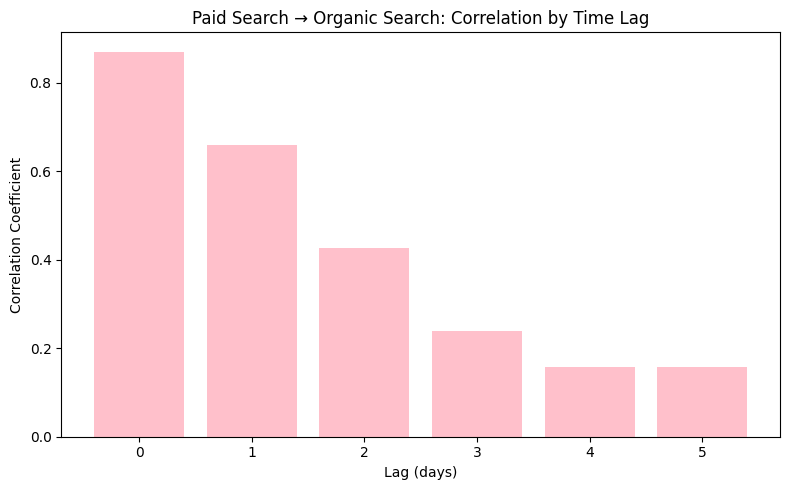

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(lag_df["lag_days"], lag_df["correlation"], color="pink")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation Coefficient")
plt.title("Paid Search → Organic Search: Correlation by Time Lag")
plt.tight_layout()
plt.show()

| Lag (days) | r | p-value |
|---|---|---|
| 0 | 0.870 | 2.14 × 10⁻²⁹ |
| 1 | 0.659 | 1.22 × 10⁻¹² |
| 2 | 0.426 | 2.89 × 10⁻⁵ |
| 3 | 0.238 | 0.0245 |
| 4 | 0.157 | 0.144 |
| 5 | 0.158 | 0.143 |

Correlation **decays monotonically** as the lag increases, from 0.87 at lag 0 down to statistically insignificant by lag 4 (p = 0.144, well above even the unadjusted 0.05 threshold). With 6 lags tested, the Bonferroni-adjusted threshold is 0.05 / 6 = **0.0083** — under this stricter standard, only lag 0, 1, and 2 remain significant; lag 3 (p = 0.0245) would have passed the standard 0.05 test but **fails** the multiple-comparisons-adjusted one, illustrating exactly why that correction matters.

If a genuine delayed halo effect existed, correlation would be expected to hold steady or show a secondary peak at some lag greater than zero, rather than decaying smoothly. The smooth, monotonic decay seen here is instead consistent with the two channels simply drifting apart as the lag pulls them further from the same point in the underlying weekly demand cycle (Section 4.2) — **there is no evidence of a delayed Paid → Organic Search effect** in this dataset; the relationship between the two channels is essentially same-day.

## 6.6 Conclusions from Correlation Analysis

- Every relationship tested in this section is **positive and statistically significant**, even after adjusting for multiple comparisons — there is no evidence anywhere in this dataset of two segments moving in opposite directions.
- The **strength of correlation varies meaningfully by dimension**: continents (r ≈ 0.77-0.79) and the three major traffic channels (r ≈ 0.81-0.87) are very tightly linked, while Social Search (r ≈ 0.58-0.60) and the top-5 product categories (r ≈ 0.51-0.67) are only moderately linked to each other.
- This pattern is consistent with a single underlying driver — the **weekly and holiday-season demand cycle identified in Section 4** — propagating through nearly every segment of the business simultaneously, rather than each continent, channel, or category having its own independent rhythm.
- **Social Search stands out as the one traffic channel with a distinct pattern**, correlating more weakly with the other three — worth investigating separately, since it may respond to different triggers (e.g. specific social campaigns or influencer activity) than the broader demand cycle driving the rest of the business.
- The **lag analysis rules out a delayed Paid → Organic Search effect**: the strong Paid/Organic relationship is a same-day phenomenon, not a multi-day halo effect, which is a useful finding for attribution modeling — Paid Search's contribution should not be credited with boosting Organic Search on subsequent days in this dataset.

# 7. Statistical Analysis of Group Differences

This section tests whether observed differences between groups are statistically significant rather than just descriptive patterns. For each comparison, a normality check (Shapiro-Wilk) determines whether a parametric test (t-test, ANOVA) is appropriate, or whether a non-parametric alternative (Mann-Whitney U, Kruskal-Wallis) is needed instead.

## 7.1 Daily Sales: Registered vs. Anonymous Users

In [ ]:
sales_registered = data[data["is_registered"]].groupby("session_date")["product_price"].sum()
sales_anonymous = data[~data["is_registered"]].groupby("session_date")["product_price"].sum()

from scipy.stats import shapiro

stat_reg, p_reg = shapiro(sales_registered)
stat_anon, p_anon = shapiro(sales_anonymous)

print(f"Registered — Shapiro-Wilk p-value: {p_reg:.4f}")
print(f"Anonymous — Shapiro-Wilk p-value: {p_anon:.4f}")

from scipy.stats import ttest_ind, mannwhitneyu

if p_reg > 0.05 and p_anon > 0.05:
    stat, p_value = ttest_ind(sales_registered, sales_anonymous, equal_var=False)
    test_used = "Independent t-test (Welch's, unequal variance)"
else:
    stat, p_value = mannwhitneyu(sales_registered, sales_anonymous, alternative="two-sided")
    test_used = "Mann-Whitney U test"

print(f"Test used: {test_used}")
print(f"Statistic: {stat:.4f}, p-value: {p_value:}")

Registered — Shapiro-Wilk p-value: 0.0073
Anonymous — Shapiro-Wilk p-value: 0.0012
Test used: Mann-Whitney U test
Statistic: 352.0000, p-value: 3.8805185465235906e-26


Both distributions fail the normality test (Shapiro-Wilk p = 0.0073 for registered, p = 0.0012 for anonymous — both well below 0.05), so the **Mann-Whitney U test** was used instead of a t-test. The result is highly significant (U = 352.0, p = 3.88 × 10⁻²⁶), confirming that daily total sales differ between the two groups.

**Important interpretive caveat:** this result should not be read as "registered users behave differently from anonymous users." Anonymous sessions outnumber registered sessions roughly 11-to-1 (92.01% vs. 7.99%, from Section 2), so anonymous *daily totals* are mechanically almost guaranteed to be larger every single day — the test is essentially confirming a population-size difference, not a behavioral one. Section 3.10 already showed conversion rate and average order value are nearly identical between registered and anonymous users on a *per-session* basis — that remains the more meaningful comparison. This result is included for completeness (as required by the assignment) but should be interpreted alongside that earlier, more informative finding rather than in isolation.

### Distribution Visualization

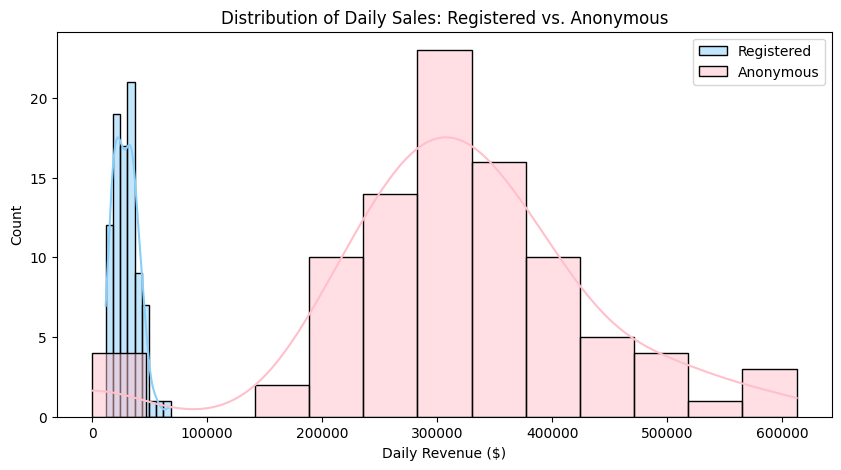

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(sales_registered, color="lightskyblue", label="Registered", kde=True, alpha=0.5)
sns.histplot(sales_anonymous, color="pink", label="Anonymous", kde=True, alpha=0.5)
plt.xlabel("Daily Revenue ($)")
plt.title("Distribution of Daily Sales: Registered vs. Anonymous")
plt.legend()
plt.show()

## 7.2 Session Count by Traffic Channel

In [ ]:
sessions_by_channel_date = data[data["traffic_channel"] != "Undefined"].groupby(
    ["session_date", "traffic_channel"]
)["session_id"].count().reset_index()

groups = [
    sessions_by_channel_date[sessions_by_channel_date["traffic_channel"] == ch]["session_id"]
    for ch in sessions_by_channel_date["traffic_channel"].unique()
]

# Normality check per group
from scipy.stats import shapiro
for ch, g in zip(sessions_by_channel_date["traffic_channel"].unique(), groups):
    print(f"{ch}: Shapiro p-value = {shapiro(g)[1]:.4f}")

    from scipy.stats import f_oneway, kruskal

stat, p_value = kruskal(*groups)
print(f"Kruskal-Wallis: statistic = {stat:.4f}, p-value = {p_value:}")

Direct: Shapiro p-value = 0.0343
Organic Search: Shapiro p-value = 0.0123
Paid Search: Shapiro p-value = 0.0108
Social Search: Shapiro p-value = 0.1413
Kruskal-Wallis: statistic = 260.4815, p-value = 3.5370311010399424e-56


Three of the four channels fail the normality test (Direct p = 0.0343, Organic Search p = 0.0123, Paid Search p = 0.0108), while only Social Search passes (p = 0.1413). Since the majority of groups are non-normal, the **Kruskal-Wallis test** (the non-parametric equivalent of one-way ANOVA for 3+ groups) was used rather than ANOVA. The result is highly significant (H = 260.48, p = 3.54 × 10⁻⁵⁶), confirming that daily session counts differ significantly across traffic channels — consistent with the very different channel volumes already established in Section 3.5 (Organic Search leading, Social Search trailing well behind).

## 7.3 Share of Organic Traffic: Europe vs. Americas

In [ ]:
europe_total = (data["continent"] == "Europe").sum()
europe_organic = ((data["continent"] == "Europe") & (data["traffic_channel"] == "Organic Search")).sum()

americas_total = (data["continent"] == "Americas").sum()
americas_organic = ((data["continent"] == "Americas") & (data["traffic_channel"] == "Organic Search")).sum()

print(f"Europe: {europe_organic}/{europe_total} organic ({europe_organic/europe_total*100:.2f}%)")
print(f"Americas: {americas_organic}/{americas_total} organic ({americas_organic/americas_total*100:.2f}%)")

from statsmodels.stats.proportion import proportions_ztest

count = [europe_organic, americas_organic]
nobs = [europe_total, americas_total]

stat, p_value = proportions_ztest(count, nobs)
print(f"Two-proportion z-test: statistic = {stat:.4f}, p-value = {p_value:.6f}")

Europe: 23195/65135 organic (35.61%)
Americas: 68671/193179 organic (35.55%)
Two-proportion z-test: statistic = 0.2895, p-value = 0.772188


Europe and Americas show nearly identical organic-traffic shares — **35.61%** (23,195 of 65,135 sessions) vs. **35.55%** (68,671 of 193,179 sessions). A two-proportion z-test confirms there is **no statistically significant difference** (z = 0.2895, p = 0.772, far above 0.05). This is a meaningful negative result: despite Americas generating over 3× the total session volume of Europe (Section 3.1), the two regions rely on organic search for essentially the same *proportion* of their traffic — the channel mix itself doesn't vary by region, only the overall scale does.

## 7.4 Chi-square test of independence: Device Type × Registration Status

Tests whether device choice (desktop/mobile/tablet) is associated with whether a session belongs to a registered user — a categorical-vs-categorical relationship, which calls for a chi-square test rather than any of the tests above.

In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(data["device_type"], data["is_registered"])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square: statistic = {chi2:.4f}, p-value = {p_value:.6f}, dof = {dof}")

Chi-square: statistic = 2.1504, p-value = 0.341236, dof = 2


The result is **not significant** (χ² = 2.15, p = 0.341, df = 2). There is no evidence that device choice depends on registration status — registered and anonymous users choose desktop, mobile, and tablet in similar proportions, so device-type marketing or UX decisions do not need to be tailored differently by registration status.

## 7.5 Kruskal-Wallis: Average Order Value Across Top-3 Continents

Section 3.1 showed Americas generates far more *total* revenue than Asia or Europe — but does it also charge/attract higher-value individual orders, or is the revenue gap purely a matter of order *volume*? This test compares the per-order price distribution (not the daily total) across the three continents.

In [ ]:
aov_americas = purchased[purchased["continent"] == "Americas"]["product_price"]
aov_asia = purchased[purchased["continent"] == "Asia"]["product_price"]
aov_europe = purchased[purchased["continent"] == "Europe"]["product_price"]

stat, p_value = kruskal(aov_americas, aov_asia, aov_europe)
print(f"Kruskal-Wallis (AOV by continent): statistic = {stat:.4f}, p-value = {p_value:.6f}")

Kruskal-Wallis (AOV by continent): statistic = 2.9032, p-value = 0.234198


The result is **not significant** (H = 2.90, p = 0.234). Average order value does **not** differ significantly across Americas, Asia, and Europe. This is an important clarification of the Section 3.1 finding: Americas' revenue dominance comes entirely from having **more orders**, not from **higher-value orders** — customers across all three continents spend similarly per purchase; the difference in scale is purely about traffic and order volume.

## 7.6 Conclusions from Group Difference Testing

- The registered-vs-anonymous sales comparison (7.1) is statistically significant, but this reflects the two groups' very different population sizes rather than a genuine behavioral difference — a reminder that **statistical significance is not the same as practical significance**, and the metric being tested (daily totals vs. per-session averages) matters as much as the test itself.
- Session volume differs significantly across traffic channels (7.2), as expected given their very different scales established earlier in this project.
- Two results were **not significant** and are just as informative as the significant ones: organic traffic share is essentially identical between Europe and Americas (7.3), and device choice is independent of registration status (7.4a) — both suggest these are structural, channel/audience-wide behaviors rather than segment-specific ones.
- The AOV-by-continent test (7.4b) is the most business-relevant negative result in this section: it confirms that **Americas' revenue lead is a volume story, not a pricing/spending-power story** — a distinction that matters for how the business should think about growth in Asia and Europe (driving more traffic/orders, not necessarily targeting higher-value baskets).

# 8. Tableau Dashboard

The findings from Sections 3-7 are summarized into a two-page interactive dashboard built in Tableau Public, covering sales performance by geography/category/device/channel on the first page and time dynamics plus the subscriber/registration breakdown on the second.

**Dashboard links:**
- [Page 1 — Sales Performance Overview](https://public.tableau.com/app/profile/kateryna.kolesnyk/viz/SalesPerformanceOverview_17879385315220/Dashboard4)
- [Page 2 — Trends & Customer Behavior](https://public.tableau.com/app/profile/kateryna.kolesnyk/viz/TrendsCustomerBehavior/Dashboard5)